In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from pmdarima.arima import ndiffs
from sklearn.metrics import mean_absolute_error
from utils import meanMAE

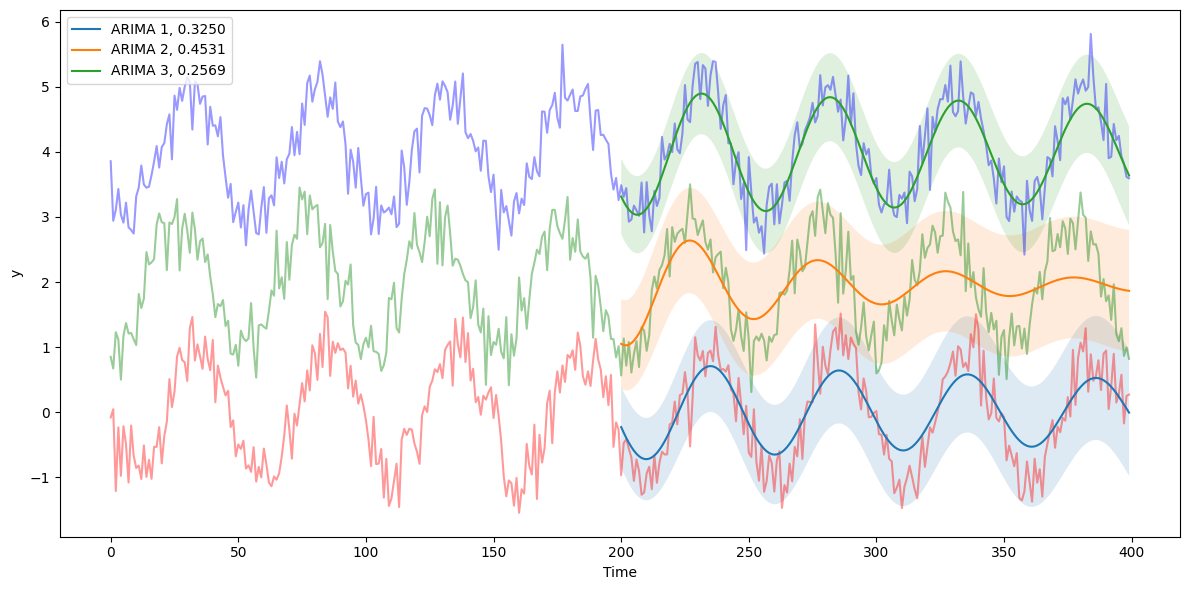

In [ ]:
np.random.seed(0)

n = 400
t = np.arange(n)
n_traj = 3

signals = []
#b=[2*i for i in range(n_traj)]
c=2
for i in range(n_traj):
    phase = np.random.uniform(0, 2*np.pi)

    signal = np.sin(2*np.pi*t/50 + phase) + 0.3*np.random.randn(n)+c #+b[i]
    signals.append(pd.Series(signal))

split = 200

plt.figure(figsize=(12, 6))

colors=['red','green','blue']

for i, data in enumerate(signals):
    model = auto_arima(
        data.iloc[:split],
        seasonal=True,
        suppress_warnings=True,
    )

    result = model.arima_res_
    steps = len(data) - split
    test = data.iloc[split:]

    forecast_res = result.get_forecast(steps=steps)
    ci = forecast_res.conf_int(alpha=0.05)
    ci.index = test.index

    plt.plot(data.index, data, alpha=0.4, color=colors[i])
    plt.plot(test.index, forecast_res.predicted_mean, label=f"ARIMA {i+1}, {mean_absolute_error(data.iloc[split:], forecast_res.predicted_mean):.4f}")

#plt.title(f'MAE: {mean_absolute_error(data.iloc[split:], forecast_res.predicted_mean):.4f}\n mean MAE: {meanMAE(data.iloc[split:], sims):.4f}\n')

    plt.fill_between(
        ci.index,
        ci.iloc[:, 0],
        ci.iloc[:, 1],
        alpha=0.15
    )

plt.xlabel("Time")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()
